In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import scipy
print("scipy version:", scipy.__version__)
print("준비 완료!")

scipy version: 1.17.1
준비 완료!


In [6]:
data = {
    'temp_C':      [200, 250, 300, 350, 400, 450, 500, 550],
    'time_h':      [1,   2,   1,   3,   2,   1,   4,   2  ],
    'hardness_HV': [120, 145, 180, 210, 195, 170, 155, 140],
    'tensile_MPa': [350, 410, 490, 530, 510, 460, 420, 390],
    'sample_id':   ['S01','S02','S03','S04','S05','S06','S07','S08'],
    'temp_range':  ['low','low','low','mid','mid','mid','high','high'],
    'grade':       ['C','C','A','A','A','B','B','C']
}

df = pd.DataFrame(data)
print("Data shape:", df.shape)
df

Data shape: (8, 7)


,temp_C,time_h,hardness_HV,tensile_MPa,sample_id,temp_range,grade
0,200,1,120,350,S01,low,C
1,250,2,145,410,S02,low,C
2,300,1,180,490,S03,low,A
3,350,3,210,530,S04,mid,A
4,400,2,195,510,S05,mid,A
5,450,1,170,460,S06,mid,B
6,500,4,155,420,S07,high,B
7,550,2,140,390,S08,high,C


In [7]:
# 수치형 열만 선택해서 상관계수 계산
corr = df[['temp_C', 'time_h', 'hardness_HV', 'tensile_MPa']].corr()

print("=== 상관계수 행렬 ===")
print(corr)

# 특정 두 변수 간 상관계수만 뽑기
r_temp_hard = corr.loc['temp_C', 'hardness_HV']
r_hard_tens = corr.loc['hardness_HV', 'tensile_MPa']

print(f"\n온도 vs 경도 상관계수: {r_temp_hard:.3f}")
print(f"경도 vs 인장강도 상관계수: {r_hard_tens:.3f}")

=== 상관계수 행렬 ===
               temp_C    time_h  hardness_HV  tensile_MPa
temp_C       1.000000  0.436436     0.140699     0.102168
time_h       0.436436  1.000000     0.222332     0.148970
hardness_HV  0.140699  0.222332     1.000000     0.993623
tensile_MPa  0.102168  0.148970     0.993623     1.000000

온도 vs 경도 상관계수: 0.141
경도 vs 인장강도 상관계수: 0.994


In [8]:
# scipy로 상관계수와 p-value 동시에 계산
r, p = stats.pearsonr(df['hardness_HV'], df['tensile_MPa'])

print("=== 경도 vs 인장강도 ===")
print(f"상관계수 (r): {r:.3f}")
print(f"p-value:      {p:.4f}")

if p < 0.05:
    print("→ 통계적으로 유의미한 상관관계 (p < 0.05)")
else:
    print("→ 통계적으로 유의미하지 않음 (p >= 0.05)")

=== 경도 vs 인장강도 ===
상관계수 (r): 0.994
p-value:      0.0000
→ 통계적으로 유의미한 상관관계 (p < 0.05)


In [9]:
# 경도로 인장강도 예측하는 회귀식 만들기
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['hardness_HV'], df['tensile_MPa']
)

print("=== 선형 회귀분석 결과 ===")
print(f"기울기 (slope):     {slope:.3f}")
print(f"절편 (intercept):   {intercept:.3f}")
print(f"R² (결정계수):      {r_value**2:.3f}")
print(f"p-value:            {p_value:.4f}")
print(f"\n회귀식: tensile_MPa = {slope:.2f} × hardness_HV + {intercept:.2f}")

# 새로운 경도값으로 인장강도 예측
new_hardness = 200
predicted = slope * new_hardness + intercept
print(f"\n경도 {new_hardness} HV일 때 예측 인장강도: {predicted:.1f} MPa")

=== 선형 회귀분석 결과 ===
기울기 (slope):     2.076
절편 (intercept):   103.737
R² (결정계수):      0.987
p-value:            0.0000

회귀식: tensile_MPa = 2.08 × hardness_HV + 103.74

경도 200 HV일 때 예측 인장강도: 519.0 MPa


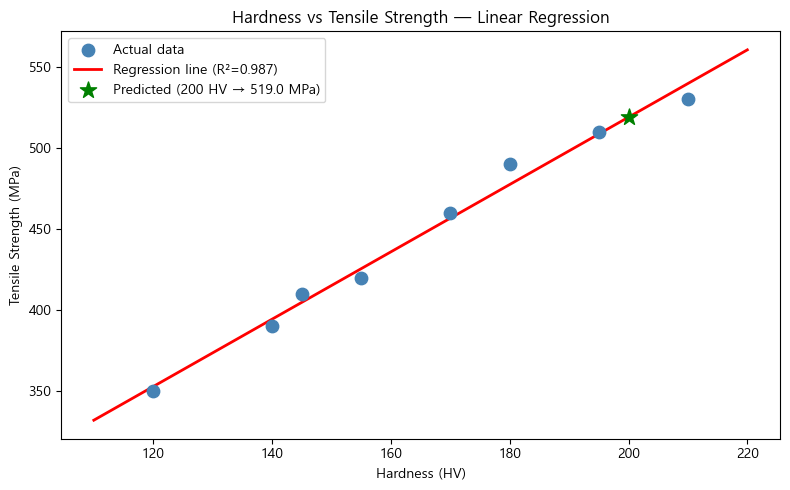

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

# 실제 데이터 점
ax.scatter(df['hardness_HV'], df['tensile_MPa'],
           color='steelblue', s=80, zorder=5, label='Actual data')

# 회귀선 그리기
x_line = np.linspace(110, 220, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='red', linewidth=2,
        label=f'Regression line (R²={r_value**2:.3f})')

# 예측값 표시 (경도 200 HV)
ax.scatter(200, predicted, color='green', s=150, zorder=6,
           marker='*', label=f'Predicted (200 HV → {predicted:.1f} MPa)')

ax.set_xlabel('Hardness (HV)')
ax.set_ylabel('Tensile Strength (MPa)')
ax.set_title('Hardness vs Tensile Strength — Linear Regression')
ax.legend()

plt.tight_layout()
plt.show()